<a href="https://colab.research.google.com/github/asheta66/CNN/blob/main/Chest%20X_Ray/Alaa_classification_chest_x_ray_Ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Chest X-Ray Classification using MobileNetV2 & EfficientNetB0
# ============================================================

# ----------------------------
# 0. Imports
# ----------------------------
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

# ----------------------------
# 1. Mount Google Drive
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ----------------------------
# 2. Configuration
# ----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4
DATA_DIR = "/content/drive/MyDrive/Chest X_Ray"
SEED = 28
TOTAL_IMAGES = 1000  # Total images after balancing

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ----------------------------
# 3. Load Image Paths
# ----------------------------
classes = ["NORMAL", "PNEUMONIA"]
image_paths = []
labels = []

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    cls_images = os.listdir(cls_dir)

    # Number of images per class
    n_per_class = TOTAL_IMAGES // len(classes)

    # Randomly select images
    selected = random.sample(cls_images, min(n_per_class, len(cls_images)))

    for fname in selected:
        image_paths.append(os.path.join(cls_dir, fname))
        labels.append(idx)

# Shuffle dataset
combined = list(zip(image_paths, labels))
random.shuffle(combined)
image_paths, labels = zip(*combined)

# ----------------------------
# 4. Image Loading
# ----------------------------
def load_and_process_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if load_and_process_image.counter < 5:
        print(f"Original size: {img.shape}")
        load_and_process_image.counter += 1

    # Grayscale -> RGB
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32)

    return img

load_and_process_image.counter = 0

X = np.array([load_and_process_image(p) for p in image_paths])
y = np.array(labels)

# ----------------------------
# 5. Dataset summary
# ----------------------------
for i, cls in enumerate(classes):
    print(f"{cls}: {np.sum(y == i)} images")
print(f"Total images: {len(y)}")

# ----------------------------
# 6. Train / Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# ----------------------------
# 7. Class counts before augmentation
# ----------------------------
before_counts = [np.sum(y_train == i) for i in range(len(classes))]

# ----------------------------
# 8. Data Augmentation
# ----------------------------
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True
)

AUG_PER_CLASS = 200

X_aug = []
y_aug = []

for cls in range(len(classes)):
    cls_indices = np.where(y_train == cls)[0]
    cls_images = X_train[cls_indices]

    count = 0

    for img in cls_images:
        img = np.expand_dims(img, axis=0)

        for batch in datagen.flow(img, batch_size=1):
            X_aug.append(batch[0])
            y_aug.append(cls)
            count += 1

            if count >= AUG_PER_CLASS:
                break

        if count >= AUG_PER_CLASS:
            break

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# ----------------------------
# 9. Merge augmented data
# ----------------------------
X_train = np.concatenate([X_train, X_aug], axis=0)
y_train = np.concatenate([y_train, y_aug], axis=0)

# ----------------------------
# 10. Class counts after augmentation
# ----------------------------
after_counts = [np.sum(y_train == i) for i in range(len(classes))]

Original size: (912, 1384)
Original size: (1768, 1992)
Original size: (1619, 1952)
Original size: (1241, 1662)
Original size: (1295, 1524)
NORMAL: 500 images
PNEUMONIA: 500 images
Total images: 1000


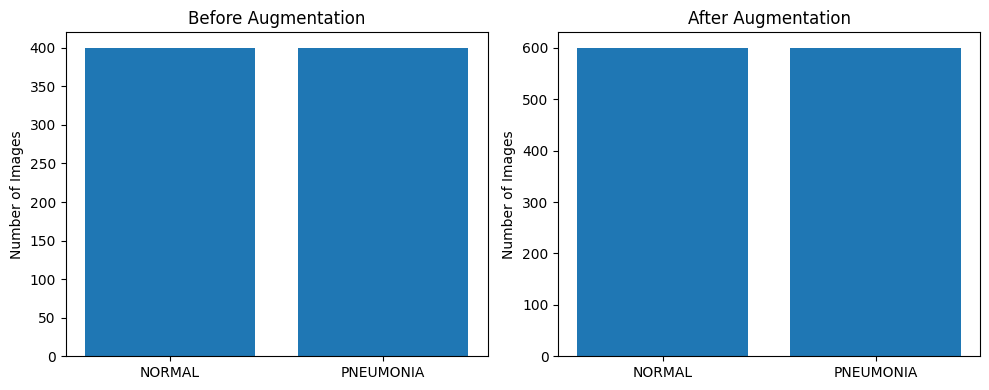


Training set before augmentation:
NORMAL: 400
PNEUMONIA: 400

Training set after augmentation:
NORMAL: 600
PNEUMONIA: 600

Test set:
NORMAL: 100
PNEUMONIA: 100

Total train samples: 1200
Total test samples: 200


In [3]:
# ----------------------------
# 11. Plot class distributions
# ----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(classes, before_counts)
plt.title("Before Augmentation")
plt.ylabel("Number of Images")

plt.subplot(1, 2, 2)
plt.bar(classes, after_counts)
plt.title("After Augmentation")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# ----------------------------
# 12. Print train/test summary
# ----------------------------
print("\nTraining set before augmentation:")
for i, cls in enumerate(classes):
    print(f"{cls}: {before_counts[i]}")

print("\nTraining set after augmentation:")
for i, cls in enumerate(classes):
    print(f"{cls}: {after_counts[i]}")

print("\nTest set:")
for i, cls in enumerate(classes):
    print(f"{cls}: {np.sum(y_test == i)}")

print(f"\nTotal train samples: {len(y_train)}")
print(f"Total test samples: {len(y_test)}")

In [4]:
# ----------------------------
# 7. Model Builder
# ----------------------------
def build_model(base_model):
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=base_model.input,
        outputs=output
    )

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ----------------------------
# 8. Prepare Data for Each Model
# ----------------------------
# Uses X_train and X_test produced in the previous section
X_train_m = mobilenet_preprocess(X_train.copy())
X_test_m  = mobilenet_preprocess(X_test.copy())

X_train_e = efficientnet_preprocess(X_train.copy())
X_test_e  = efficientnet_preprocess(X_test.copy())

# ----------------------------
# 9. Define Base Models
# ----------------------------
mobilenet_base = MobileNetV2(
    input_shape=(224, 224, 3),
    weights="imagenet",
    include_top=False
)

efficientnet_base = EfficientNetB0(
    input_shape=(224, 224, 3),
    weights="imagenet",
    include_top=False
)

# ----------------------------
# 10. Build Models
# ----------------------------
model_m = build_model(mobilenet_base)
model_e = build_model(efficientnet_base)

print("MobileNetV2 model ready")
print("EfficientNetB0 model ready")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 model ready
EfficientNetB0 model ready


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ----------------------------
# 10. Training
# ----------------------------
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history_m = model_m.fit(
    X_train_m,
    y_train,
    validation_data=(X_test_m, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

history_e = model_e.fit(
    X_train_e,
    y_train,
    validation_data=(X_test_e, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
24/38 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5626 - loss: 0.7311

In [ ]:
# ----------------------------
# 11. Evaluation Function
# ----------------------------
def evaluate_model(model, Xtr, Xte, ytr, yte):
    ytr_prob = model.predict(Xtr).ravel()
    yte_prob = model.predict(Xte).ravel()

    ytr_pred = (ytr_prob > 0.5).astype(int)
    yte_pred = (yte_prob > 0.5).astype(int)

    metrics_train = {
        "Accuracy": accuracy_score(ytr, ytr_pred),
        "Precision": precision_score(ytr, ytr_pred),
        "Recall": recall_score(ytr, ytr_pred),
        "F1": f1_score(ytr, ytr_pred)
    }

    metrics_test = {
        "Accuracy": accuracy_score(yte, yte_pred),
        "Precision": precision_score(yte, yte_pred),
        "Recall": recall_score(yte, yte_pred),
        "F1": f1_score(yte, yte_pred)
    }

    cm_train = confusion_matrix(ytr, ytr_pred)
    cm_test = confusion_matrix(yte, yte_pred)

    fpr_train, tpr_train, _ = roc_curve(ytr, ytr_prob)
    fpr_test, tpr_test, _ = roc_curve(yte, yte_prob)

    auc_train = auc(fpr_train, tpr_train)
    auc_test = auc(fpr_test, tpr_test)

    return (metrics_train, metrics_test,
            cm_train, cm_test,
            fpr_train, tpr_train, auc_train,
            fpr_test, tpr_test, auc_test)

In [ ]:
# ----------------------------
# 12. Run Evaluation (Example: MobileNetV2)
# ----------------------------
(train_metrics, test_metrics,
 cm_train, cm_test,
 fpr_train, tpr_train, auc_train,
 fpr_test, tpr_test, auc_test) = evaluate_model(
    model_m, X_train_m, X_test_m, y_train, y_test
)

In [ ]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }, y_pred


results = []

models_info = {
    "MobileNetV2": (model_m, X_train_m, X_test_m),
    "EfficientNetB0": (model_e, X_train_e, X_test_e)
}

metrics_storage = {}

for model_name, (model, Xtr, Xte) in models_info.items():

    # Predictions
    ytr_prob = model.predict(Xtr).ravel()
    yte_prob = model.predict(Xte).ravel()

    # Metrics
    train_metrics, ytr_pred = compute_metrics(y_train, ytr_prob)
    test_metrics,  yte_pred = compute_metrics(y_test,  yte_prob)

    # Store for later plots
    metrics_storage[model_name] = {
        "ytr_prob": ytr_prob,
        "yte_prob": yte_prob,
        "ytr_pred": ytr_pred,
        "yte_pred": yte_pred,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics
    }

    results.append([model_name, "Train", *train_metrics.values()])
    results.append([model_name, "Test",  *test_metrics.values()])


df_results = pd.DataFrame(
    results,
    columns=["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1"]
)

print("\n📊 Performance Summary (Both Models):")
display(df_results)


In [ ]:
for model_name, data in metrics_storage.items():

    cm_train = confusion_matrix(y_train, data["ytr_pred"])
    cm_test  = confusion_matrix(y_test,  data["yte_pred"])

    plt.figure(figsize=(10,4))

    for i, (cm, title) in enumerate(
        zip([cm_train, cm_test], ["Train", "Test"])
    ):
        plt.subplot(1,2,i+1)
        plt.imshow(cm, cmap="YlOrBr", alpha=0.7)
        plt.title(f"{model_name} – {title} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar()

        # 🔹 Numbers inside matrix
        for r in range(cm.shape[0]):
            for c in range(cm.shape[1]):
                plt.text(c, r, cm[r, c],
                         ha="center", va="center",
                         color="black", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()


In [ ]:
for model_name, data in metrics_storage.items():

    fpr_train, tpr_train, _ = roc_curve(y_train, data["ytr_prob"])
    fpr_test,  tpr_test,  _ = roc_curve(y_test,  data["yte_prob"])

    auc_train = auc(fpr_train, tpr_train)
    auc_test  = auc(fpr_test,  tpr_test)

    plt.figure(figsize=(5,4))

    plt.plot(
        fpr_train, tpr_train,
        label=f"Train ROC (AUC = {auc_train:.3f})",
        linewidth=2
    )

    plt.plot(
        fpr_test, tpr_test,
        label=f"Test ROC (AUC = {auc_test:.3f})",
        linewidth=2
    )

    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} – ROC Curve (Train vs Test)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{model_name}_roc_curve.png")
    plt.show()


In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_m.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history_m.history['val_accuracy'], label='Test Accuracy', linewidth=2)
plt.title('MobileNetV2 – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_m.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_m.history['val_loss'], label='Test Loss', linewidth=2)
plt.title('MobileNetV2 – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('MobileNetV2 Training vs Testing Performance')
plt.tight_layout()
plt.savefig("mobilenet_performance.png")
plt.show()


In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_e.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history_e.history['val_accuracy'], label='Test Accuracy', linewidth=2)
plt.title('EfficientNet-B0 – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_e.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_e.history['val_loss'], label='Test Loss', linewidth=2)
plt.title('EfficientNet-B0 – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('EfficientNet-B0 Training vs Testing Performance')
plt.tight_layout()
plt.savefig("efficientnet_performance.png")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Filter TEST results only
df_test = df_results[df_results["Dataset"] == "Test"]

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = df_test["Model"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(6,4))

# Bars for each model
plt.bar(
    x - width/2,
    df_test.loc[df_test["Model"] == "MobileNetV2", metrics].values.flatten(),
    width,
    label="MobileNetV2",
    color="#FFD700"   # Yellow
)

plt.bar(
    x + width/2,
    df_test.loc[df_test["Model"] == "EfficientNetB0", metrics].values.flatten(),
    width,
    label="EfficientNet-B0",
    color="#8B4513"   # Brown
)

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.title("Model Performance Comparison (Test Set)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("model_performance_comparison.png")
plt.show()
